In [15]:
import numpy as np
import torch
from matplotlib import pyplot as plt

from multilinear import MultiLinear

# Bilinear
NOTE: this notebook is out of date and will not run.

From before scattering was incorporated into the multilinear architecture to be computed on each pass.

Instantiated model with 6 params.


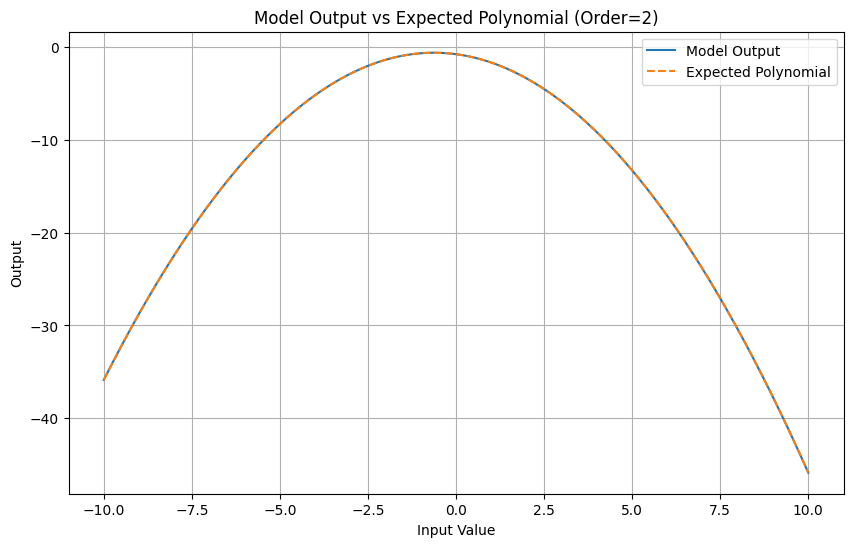

In [34]:
model = MultiLinear(1, order=2, num_features=1)
model.eval()

w1 = model.w[0].weight.item()
b1 = model.w[0].bias.item()
w2 = model.w[1].weight.item()
b2 = model.w[1].bias.item()

v = model.v.weight.item()
v_b = model.v.bias.item()

X = np.linspace(-10, 10, 1000)

outputs = []
expected = []

for x in X:
    x_tensor = torch.from_numpy(np.array([[x]], dtype=np.float32))
    outputs.append(model(x_tensor).item())

    term1 = w1 * x + b1
    term2 = w2 * x + b2
    expected_output = v * (term1 * term2) + v_b
    expected.append(expected_output)

plt.figure(figsize=(10, 6))
plt.plot(X, outputs, label='Model Output')
plt.plot(X, expected, label='Expected Polynomial', linestyle='--')
plt.title('Model Output vs Expected Polynomial (Order=2)')
plt.xlabel('Input Value')
plt.ylabel('Output')
plt.legend()
plt.grid(True)

assert np.allclose(outputs, expected, rtol=1e-5, atol=1e-5)

# Trilinear

Instantiated model with 8 params.


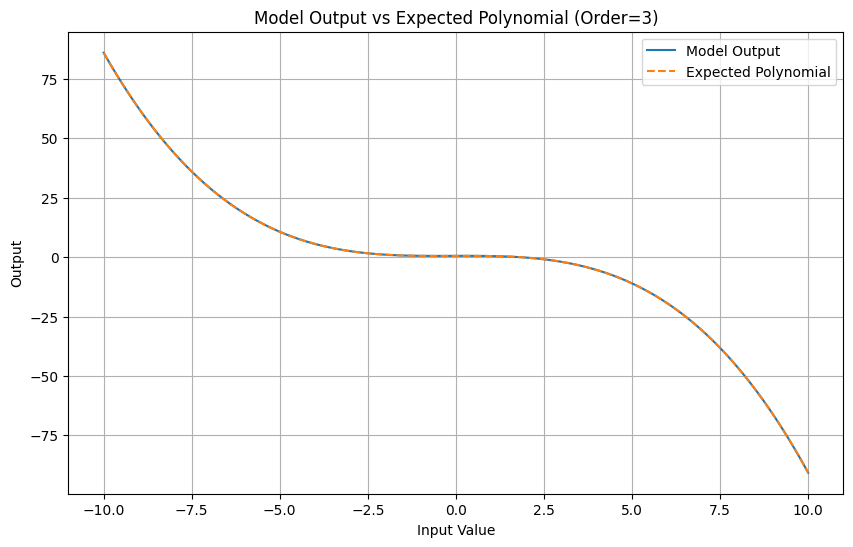

In [35]:
model = MultiLinear(1, order=3, num_features=1)
model.eval()

w1 = model.w[0].weight.item()
b1 = model.w[0].bias.item()
w2 = model.w[1].weight.item()
b2 = model.w[1].bias.item()
w3 = model.w[2].weight.item()
b3 = model.w[2].bias.item()

v = model.v.weight.item()
v_b = model.v.bias.item()

X = np.linspace(-10, 10, 1000)

outputs = []
expected = []

for x in X:
    x_tensor = torch.from_numpy(np.array([[x]], dtype=np.float32))
    outputs.append(model(x_tensor).item())

    term1 = w1 * x + b1
    term2 = w2 * x + b2
    term3 = w3 * x + b3
    expected_output = v * (term1 * term2 * term3) + v_b
    expected.append(expected_output)

plt.figure(figsize=(10, 6))
plt.plot(X, outputs, label='Model Output')
plt.plot(X, expected, label='Expected Polynomial', linestyle='--')
plt.title('Model Output vs Expected Polynomial (Order=3)')
plt.xlabel('Input Value')
plt.ylabel('Output')
plt.legend()
plt.grid(True)

assert np.allclose(outputs, expected, rtol=1e-3, atol=1e-3)

## Multidimensional x

In [86]:
input_dim = 3
order = 3
num_features = 2
num_samples = 1000

model = MultiLinear(input_dim=input_dim, order=order, num_features=num_features)
model.eval()

w1 = model.w[0].weight.detach().numpy()
b1 = model.w[0].bias.detach().numpy()
w2 = model.w[1].weight.detach().numpy()
b2 = model.w[1].bias.detach().numpy()
w3 = model.w[2].weight.detach().numpy()
b3 = model.w[2].bias.detach().numpy()

v_weight = model.v.weight.detach().numpy()
v_bias = model.v.bias.item()

X = np.random.uniform(-10, 10, (num_samples, input_dim)).astype(np.float32)

outputs = []
expected = []

for i in range(num_samples):
    x = X[i:i + 1]
    output = model(torch.from_numpy(x)).item()
    outputs.append(output)
    product_terms = np.ones(num_features)
    for f in range(num_features):
        term1 = np.dot(w1[f], x.T) + b1[f]
        term2 = np.dot(w2[f], x.T) + b2[f]
        term3 = np.dot(w3[f], x.T) + b3[f]
        product = (term1 * term2 * term3)[0]
        product_terms[f] = product

    expected_output = np.dot(v_weight, product_terms).item() + v_bias
    expected.append(expected_output)

assert np.allclose(outputs, expected, rtol=1e-5, atol=1e-5)

Instantiated model with 27 params.
